In [ ]:
from pathlib import Path

base_dir = '/users/lorin.ng/SURIP2026/data'
os.chdir(base_dir)

indir = Path("/users/shared.user/Summer2026/cogwheel_O4_gaussian_injections/PE/IntrinsicLVCPrior/")

import numpy as np

np.loadtxt(unlensed_data / "MD_SDSS_u_0/run_0/summary.txt")

In [2]:
import os

# 將路徑更改為你的 data 目錄
target_path = '/users/lorin.ng/SURIP2026/data'
os.chdir(target_path)

# 驗證是否真的成功切換
print(f"現在的工作目錄已經變更為: {os.getcwd()}")

現在的工作目錄已經變更為: /users/lorin.ng/SURIP2026/data


In [4]:
import pandas as pd

# 這是 GWOSC 的官方 API 下載連結
# 直接抓取 GWTC-5.0 (包含 O4b) 的所有數據
url = "https://gwosc.org/eventapi/csv/GWTC-5.0/"

try:
    print("正在從 GWOSC 下載數據...")
    df = pd.read_csv(url)
    
    # 將檔案存到你的電腦，命名為 o4b_events.csv
    df.to_csv('o4b_events.csv', index=False)
    
    print("下載成功！檔案已儲存為 'o4b_events.csv'")
    print(f"共抓取到 {len(df)} 個事件。")
    print("\n前 5 列數據預覽：")
    print(df[['commonName', 'mass_1_source', 'mass_2_source', 'network_matched_filter_snr']].head())

except Exception as e:
    print(f"下載失敗，錯誤訊息：{e}")

正在從 GWOSC 下載數據...
下載成功！檔案已儲存為 'o4b_events.csv'
共抓取到 161 個事件。

前 5 列數據預覽：
        commonName  mass_1_source  mass_2_source  network_matched_filter_snr
0  GW240406_062847            NaN            NaN                        11.3
1  GW240407_040938            NaN            NaN                         8.5
2  GW240407_061416            NaN            NaN                         8.8
3  GW240407_214946            NaN            NaN                         7.5
4  GW240408_081753            NaN            NaN                         8.3


/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


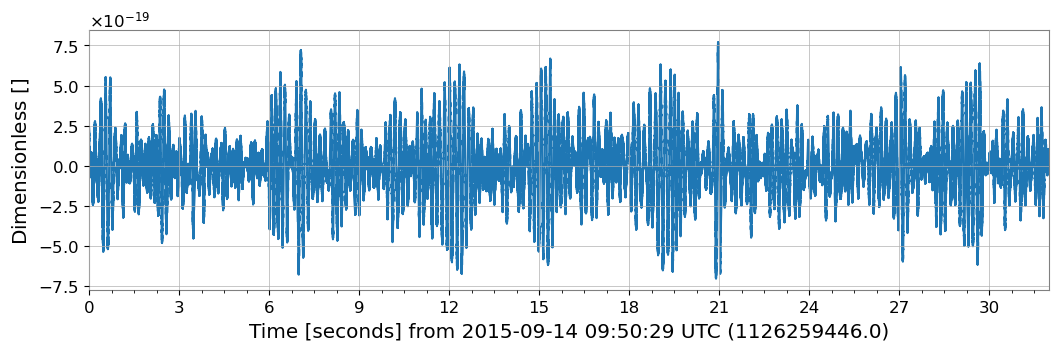

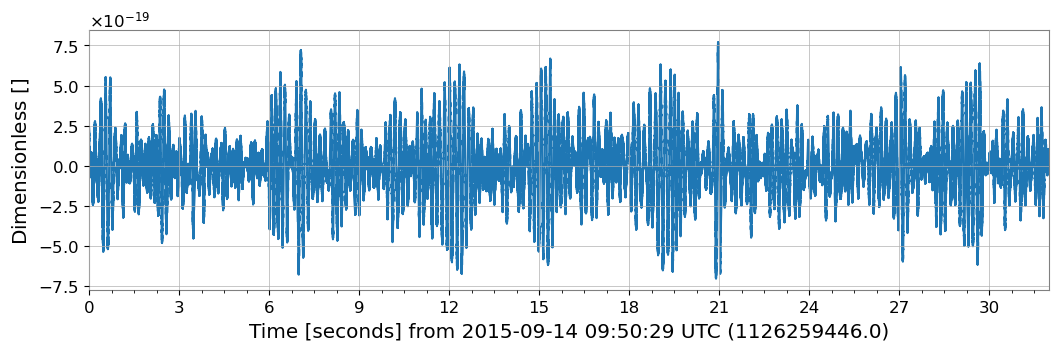

In [1]:
from gwpy.timeseries import TimeSeries
# 獲取 GW150914 事件附近的數據
data = TimeSeries.fetch_open_data('H1', 1126259446, 1126259478)
data.plot()

In [ ]:
npz_file = np.load(indir / 'MD_SDSS_u_167/npz')
list(npz_file.keys())

In [ ]:
import pandas as pd
import glob
import os

O4_base_path = '/users/shared.user/Summer2026/cogwheel_O4_gaussian_injections/PE'
search_pattern = os.path.join(O4_base_path, 'O4_MD_SDSS_lensed_pairs*.csv')
O4_files = glob.glob(search_pattern)

all_O4_m1_m2_data = []

for O4_file in O4_files:
    # 讀取 CSV
    df_O4 = pd.read_csv(O4_file)
    
    # 只提取 m1, m2
    O4_subset = df_O4[['m1', 'm2']].dropna()
    
    all_O4_m1_m2_data.append(O4_subset)

# 合併所有 O4 數據
if len(all_O4_m1_m2_data) > 0:
    combined_O4_df = pd.concat(all_O4_m1_m2_data, ignore_index=True)
    print(f"✅ 成功提取所有 O4 數據！總共有 {len(combined_O4_df)} 筆樣本。")
    print(combined_O4_df.head())
else:
    print("錯誤：未能讀取到任何 O4 檔案。請再次檢查路徑拼寫。")

✅ 成功提取所有 O4 數據！總共有 10000 筆樣本。
           m1          m2
0   95.403336   94.647066
1  106.390095   92.618090
2   42.068627   32.457391
3   51.585649   50.523301
4  238.526752  234.939679


In [15]:
import pandas as pd
import glob
import os

# 1. 鎖定你剛剛手動複製檔案進去的目錄
# 既然檔案在 ../data，我們就搜這裡
target_dir = '../data'
search_pattern = os.path.join(target_dir, 'O4_MD_SDSS_lensed_pairs*.csv')
files = glob.glob(search_pattern)

print(f"從 {target_dir} 抓取到的檔案: {files}")

# 2. 檢查是否抓到檔案
if not files:
    print("❌ 還是沒抓到檔案，請檢查檔案名稱是否真的以 O4 開頭！")
else:
    all_data = []
    for f in files:
        df = pd.read_csv(f)
        # 這裡改用你確認過的欄位名稱，如果報錯 KeyError，請告訴我欄位名稱
        all_data.append(df[['m1', 'm2']])
    
    # 3. 合併
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"✅ 成功合併！資料總筆數: {len(combined_df)}")
    print(combined_df.head())

從 ../data 抓取到的檔案: ['../data/O4_MD_SDSS_lensed_pairs_inj_params_0.csv', '../data/O4_MD_SDSS_lensed_pairs_inj_params_1.csv']
✅ 成功合併！資料總筆數: 10000
           m1          m2
0   95.403336   94.647066
1  106.390095   92.618090
2   42.068627   32.457391
3   51.585649   50.523301
4  238.526752  234.939679


In [20]:
import pandas as pd
import glob

# 1. 既然你已經在 /data 目錄下，直接使用當前目錄搜尋
# 使用 O4 (字母 O) 開頭來匹配你的檔案
files = glob.glob('O4_MD_SDSS_lensed_pairs*.csv')

print(f"找到的檔案: {files}")

if len(files) >= 2:
    # 2. 讀取並合併
    df0 = pd.read_csv(files[0])
    df1 = pd.read_csv(files[1])
    
    # 提取 m1, m2
    df0_subset = df0[['m1', 'm2']]
    df1_subset = df1[['m1', 'm2']]
    
    combined_df = pd.concat([df0_subset, df1_subset], ignore_index=True)
    
    print("✅ 成功合併數據！")
    print(combined_df.head())
else:
    print("❌ 還是找不到檔案，請確認檔案名稱是否包含 O4！")

找到的檔案: ['O4_MD_SDSS_lensed_pairs_inj_params_0.csv', 'O4_MD_SDSS_lensed_pairs_inj_params_1.csv']
✅ 成功合併數據！
           m1          m2
0   95.403336   94.647066
1  106.390095   92.618090
2   42.068627   32.457391
3   51.585649   50.523301
4  238.526752  234.939679


In [21]:
from IPython.display import display

# 將數據顯示為互動式表格
display(combined_df)

,m1,m2
0,95.403336,94.647066
1,106.390095,92.618090
2,42.068627,32.457391
3,51.585649,50.523301
4,238.526752,234.939679
...,...,...
9995,21.838379,17.515316
9996,78.305783,63.636841
9997,123.474698,93.330941
9998,90.701236,76.913551


In [29]:
import numpy as np

# 1. 計算總質量 (Total Mass)
combined_df['M_total'] = combined_df['m1'] + combined_df['m2']

# --- 在這裡加入排序修正 ---
# 確保 m1 是較大的值，m2 是較小的值
sorted_masses = np.sort(combined_df[['m1', 'm2']].values, axis=1)[:, ::-1]
combined_df['m1'] = sorted_masses[:, 0]
combined_df['m2'] = sorted_masses[:, 1]
# -------------------------

# 2. 計算質量比 (Mass Ratio) - 現在 q 必定 <= 1
combined_df['q'] = combined_df['m2'] / combined_df['m1']

# 3. 計算啁啾質量 (Chirp Mass)
combined_df['chirp_mass'] = (combined_df['m1'] * combined_df['m2'])**(3/5) / (combined_df['m1'] + combined_df['m2'])**(1/5)

# 4. 計算對稱質量比 (eta)
combined_df['eta'] = (combined_df['m1'] * combined_df['m2']) / (combined_df['m1'] + combined_df['m2'])**2

print("✅ 已成功修正質量排序並計算物理參數！")

✅ 已成功修正質量排序並計算物理參數！


In [31]:
import os

# 1. 確保路徑明確指向 data 資料夾
# 為了保險起見，我們使用 os.path.join 來組合路徑
save_path = os.path.join('../data', 'O4_combined_data.csv')

# 2. 儲存檔案
combined_df.to_csv(save_path, index=False)

print(f"✅ 檔案已成功儲存至: {save_path}")

✅ 檔案已成功儲存至: ../data/O4_combined_data.csv


✅ 圖表已成功修正並儲存至: ../plots/chirp_mass_and_q_distribution_fixed.png


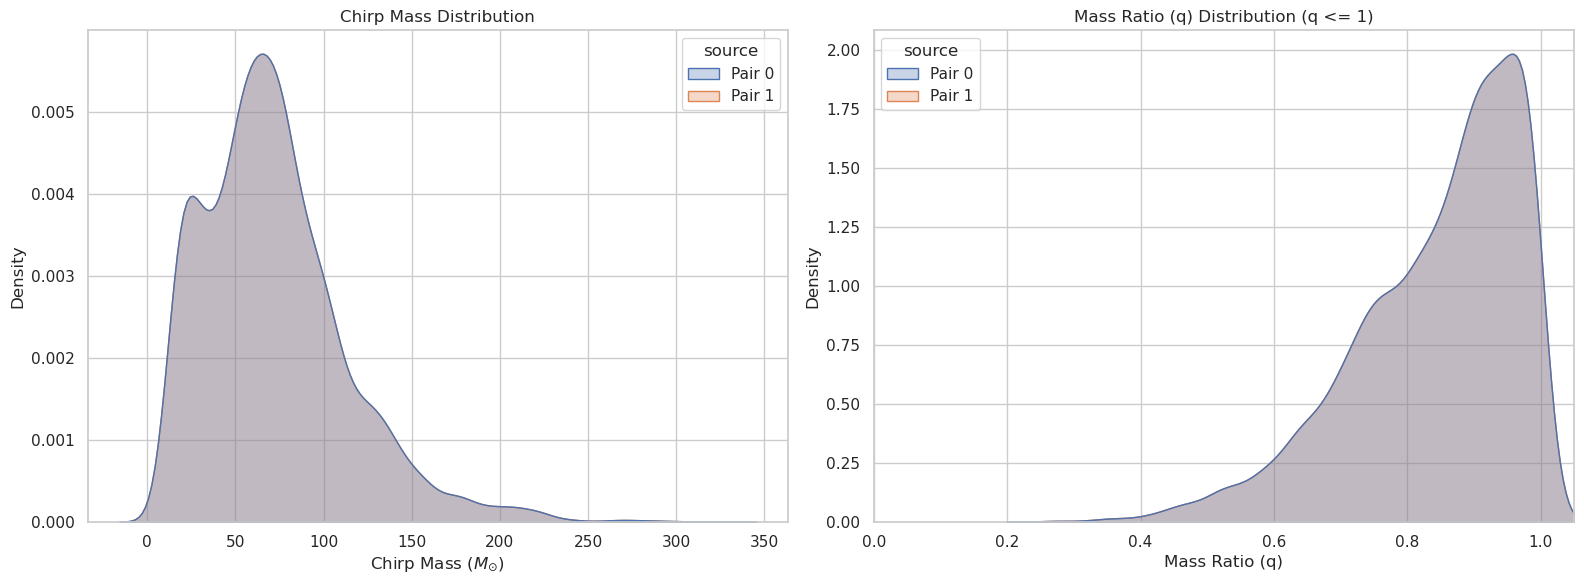

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np # 確保匯入了 numpy

# 1. 確保目錄存在
plot_dir = '../plots'
os.makedirs(plot_dir, exist_ok=True)

# 2. 讀取數據
df = pd.read_csv('../data/O4_combined_data.csv')

# --- 修正區塊：強制排序 m1, m2 ---
# 確保 m1 是較大的值，m2 是較小的值
sorted_masses = np.sort(df[['m1', 'm2']].values, axis=1)[:, ::-1]
df['m1'] = sorted_masses[:, 0]
df['m2'] = sorted_masses[:, 1]

# 重新計算 q (現在 q 必 <= 1)
df['q'] = df['m2'] / df['m1']
# ------------------------------

# 3. 分割資料集
df_0 = df.iloc[:5000].copy()
df_0['source'] = 'Pair 0'
df_1 = df.iloc[5000:].copy()
df_1['source'] = 'Pair 1'
df_combined = pd.concat([df_0, df_1])

# 4. 繪圖
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左圖：Chirp Mass
sns.kdeplot(data=df_combined, x='chirp_mass', hue='source', fill=True, ax=axes[0], alpha=0.3)
axes[0].set_title('Chirp Mass Distribution')
axes[0].set_xlabel('Chirp Mass ($M_{\odot}$)')

# 右圖：q (Mass Ratio)
sns.kdeplot(data=df_combined, x='q', hue='source', fill=True, ax=axes[1], alpha=0.3)
axes[1].set_title('Mass Ratio (q) Distribution (q <= 1)')
axes[1].set_xlabel('Mass Ratio (q)')
axes[1].set_xlim(0, 1.05) # 強制限制 x 軸範圍

plt.tight_layout()

# 5. 存檔與顯示
plot_save_path = os.path.join(plot_dir, 'chirp_mass_and_q_distribution_fixed.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')

print(f"✅ 圖表已成功修正並儲存至: {plot_save_path}")
plt.show()

In [ ]:
import pandas as pd
from pathlib import Path

path = Path('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather')
print('path exists:', path.exists())
if path.exists():
    df = pd.read_feather(path)
    print('columns:', df.columns.tolist())
    print('shape:', df.shape)
    print('\nhead:')
    print(df.head().to_string(index=False))

✅ 數據已修正：所有 q 值均小於等於 1。


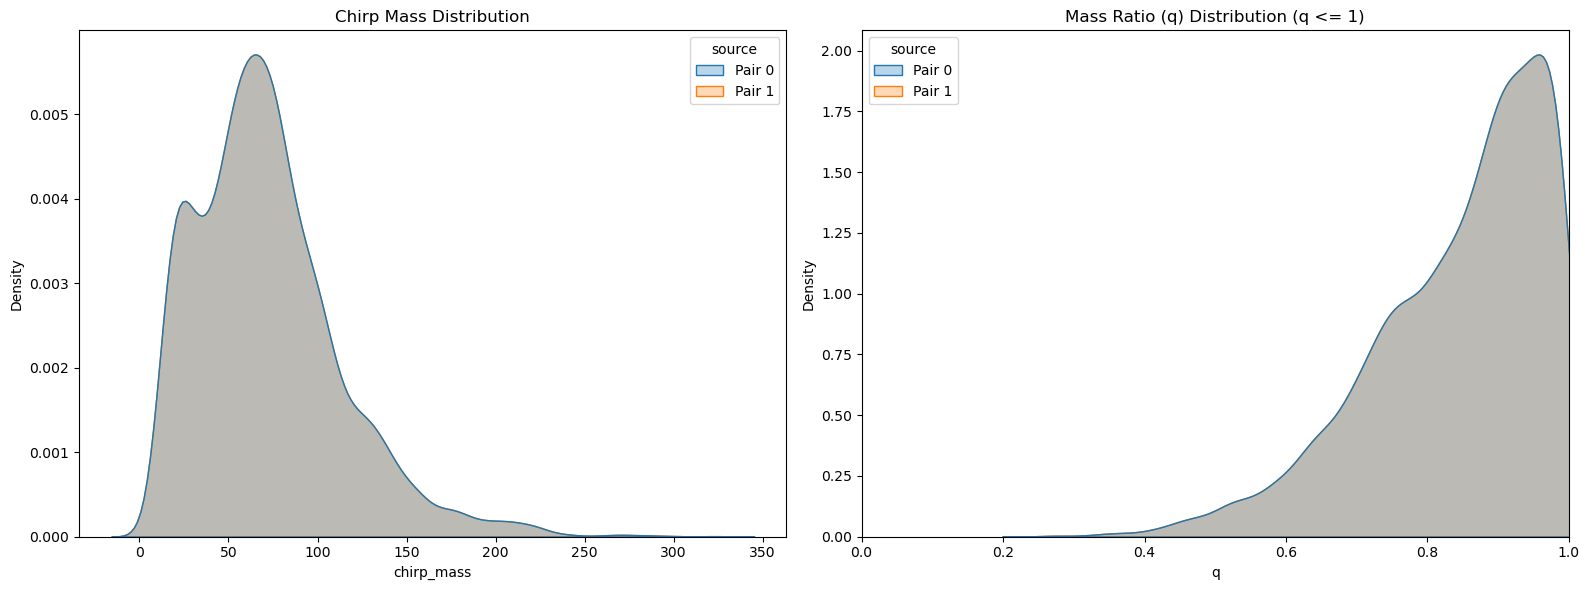

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 重新讀取原始 CSV (確保從乾淨的狀態開始)
df = pd.read_csv('../data/O4_combined_data.csv')

# 2. 強制執行排序修正 (針對所有數據)
# 確保每一行的 m1 >= m2
sorted_masses = np.sort(df[['m1', 'm2']].values, axis=1)[:, ::-1]
df['m1'] = sorted_masses[:, 0]
df['m2'] = sorted_masses[:, 1]

# 3. 重新計算 q 並確保嚴格檢查
df['q'] = df['m2'] / df['m1']

# 檢核點：如果這裡還大於 1，說明原始資料有異常
if df['q'].max() > 1.0:
    print(f"⚠️ 警告：修正後 q 仍然存在大於 1 的值，最大值為: {df['q'].max()}")
else:
    print("✅ 數據已修正：所有 q 值均小於等於 1。")

# 4. 分割資料集
df_0 = df.iloc[:5000].copy()
df_0['source'] = 'Pair 0'
df_1 = df.iloc[5000:].copy()
df_1['source'] = 'Pair 1'
df_combined = pd.concat([df_0, df_1])

# 5. 繪圖
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chirp Mass
sns.kdeplot(data=df_combined, x='chirp_mass', hue='source', fill=True, ax=axes[0], alpha=0.3)
axes[0].set_title('Chirp Mass Distribution')

# Mass Ratio (q)
sns.kdeplot(data=df_combined, x='q', hue='source', fill=True, ax=axes[1], alpha=0.3)
axes[1].set_title('Mass Ratio (q) Distribution (q <= 1)')
axes[1].set_xlim(0, 1.0) # 強制限制範圍

plot_save_path = os.path.join(plot_dir, 'chirp_mass_and_q_distribution.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')

In [1]:
# 確認檔案是否存在於該路徑
import os
print(os.path.exists('../data/O4_combined_data.csv'))

# 直接讀取並顯示前幾行數據
import pandas as pd
df = pd.read_csv('../data/O4_combined_data.csv')
print(df.head())

True
           m1          m2     M_total         q  chirp_mass       eta
0   95.403336   94.647066  190.050402  0.992073   82.723456  0.249996
1  106.390095   92.618090  199.008185  0.870552   86.374197  0.248803
2   42.068627   32.457391   74.526018  0.771534   32.114531  0.245842
3   51.585649   50.523301  102.108951  0.979406   44.442616  0.249973
4  238.526752  234.939679  473.466431  0.984962  206.081137  0.249986


目前 DataFrame 的欄位: ['m1', 'm2', 'M_total', 'q', 'chirp_mass', 'eta', 'ra', 'dec', 'source']


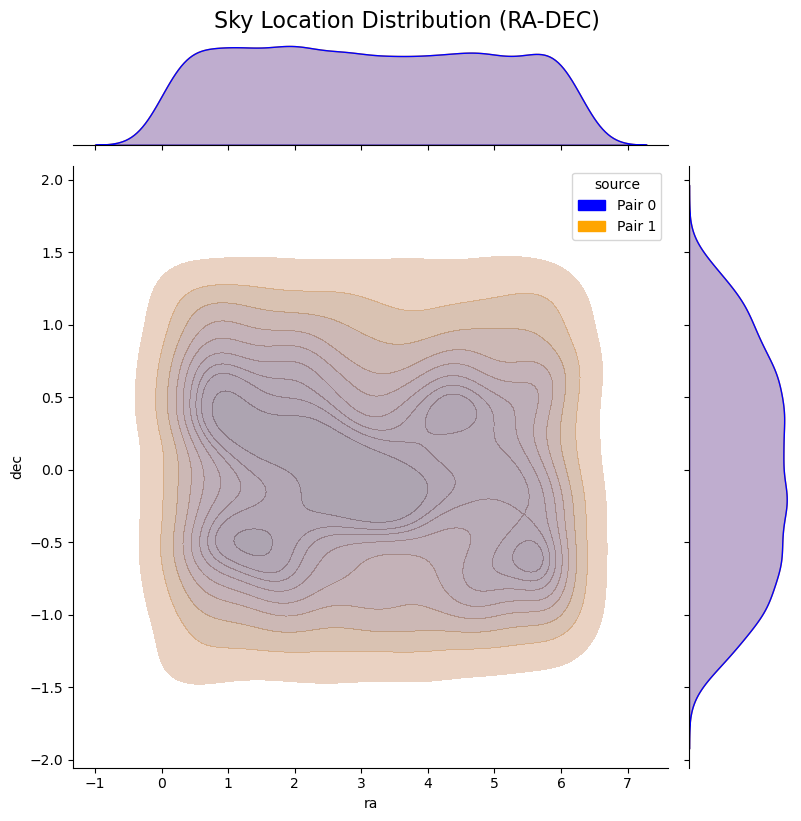

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. 讀取並建立基礎數據 (假設你已經確保原始 CSV 存在)
df_combined = pd.read_csv('../data/O4_combined_data.csv')
raw_params_0 = pd.read_csv('../data/O4_MD_SDSS_lensed_pairs_inj_params_0.csv')
raw_params_1 = pd.read_csv('../data/O4_MD_SDSS_lensed_pairs_inj_params_1.csv')

# 2. 合併原始 RA/DEC 數據 (確保長度匹配)
full_raw_params = pd.concat([raw_params_0, raw_params_1], ignore_index=True)

# 3. 補齊欄位 (這是關鍵：確保 df_combined 被正確修改)
df_combined['ra'] = full_raw_params['ra'].values
df_combined['dec'] = full_raw_params['dec'].values
df_combined['source'] = ['Pair 0'] * 5000 + ['Pair 1'] * 5000

# 4. 再次檢查欄位是否存在
print("目前 DataFrame 的欄位:", df_combined.columns.tolist())

# 5. 執行繪圖
colour = {'Pair 0': 'blue', 'Pair 1': 'orange'}
g = sns.jointplot(
    data=df_combined, 
    x='ra', 
    y='dec', 
    hue='source', 
    kind='kde', 
    fill=True, 
    alpha=0.3,
    palette=colour,
    height=8
)

g.fig.suptitle('Sky Location Distribution (RA-DEC)', fontsize=16, y=1.02)
plot_save_path = '../plots/sky_location_distribution.png'
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')

In [4]:
import numpy as np
import pandas as pd
import os
from scipy.stats import gaussian_kde

# 1. 確保數據路徑與讀取 (請確認 base_path 設定正確)
base_path = os.path.expanduser('~/SURIP2026/data/2_images_samples/')
dir_0 = os.path.join(base_path, 'MD_SDSS_l2_0_0/run_0/samples.feather')
dir_1 = os.path.join(base_path, 'MD_SDSS_l2_0_1/run_0/samples.feather')

# 2. 重新讀取數據
df_0 = pd.read_feather(dir_0)
df_1 = pd.read_feather(dir_1)

# 3. 合併樣本
combined_mchirp = np.concatenate([df_0['mchirp'].to_numpy(), df_1['mchirp'].to_numpy()])

# 4. 計算 KDE 與峰值
kde_combined = gaussian_kde(combined_mchirp)
x_grid = np.linspace(combined_mchirp.min(), combined_mchirp.max(), 1000)
density_combined = kde_combined(x_grid)

peak_combined = x_grid[np.argmax(density_combined)]

print(f"合併兩組影像後的總體啁啾質量峰值: {peak_combined:.4f}")

合併兩組影像後的總體啁啾質量峰值: 87.0162


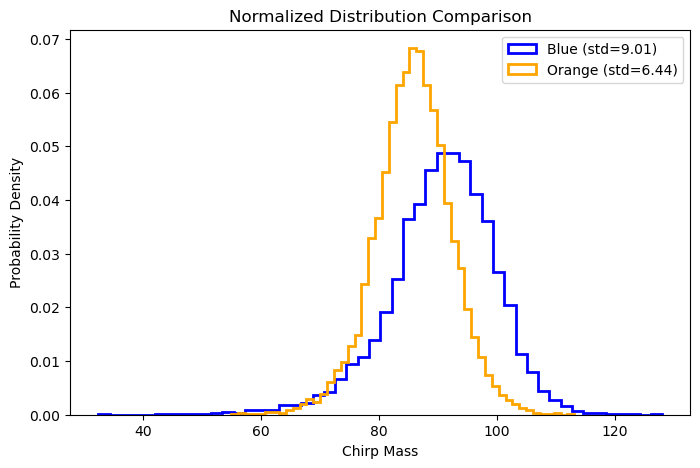

In [6]:
plt.figure(figsize=(8, 5))
# 畫出藍色與橘色的 mchirp 分佈
plt.hist(df_0['mchirp'], bins=50, density=True, histtype='step', color='blue', label='Blue (std=9.01)', lw=2)
plt.hist(df_1['mchirp'], bins=50, density=True, histtype='step', color='orange', label='Orange (std=6.44)', lw=2)

plt.xlabel('Chirp Mass')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Normalized Distribution Comparison')
plt.show()

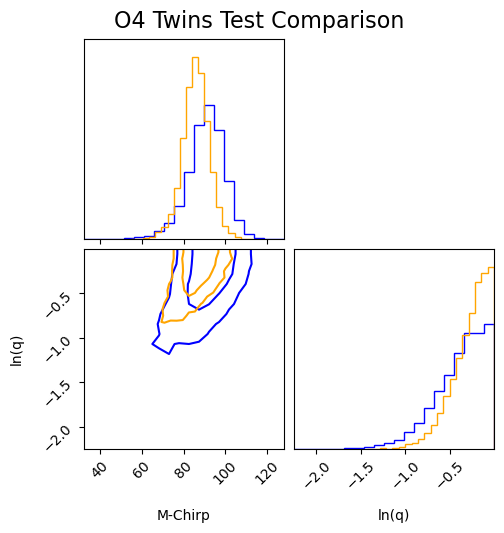

In [14]:
import numpy as np

# 1. 定義計算函數
def get_mchirp_and_lnq(df):
    m1 = df['mass_1']
    m2 = df['mass_2']
    # 計算 Chirp Mass
    mchirp = (m1 * m2)**0.6 / (m1 + m2)**0.2
    # 計算 ln(q)，其中 q = m2/m1 (假設 m2 <= m1)
    q = m2 / m1
    lnq = np.log(q)
    return np.column_stack([mchirp, lnq])

# 2. 獲取數據
data_0 = get_mchirp_and_lnq(df_0)
data_1 = get_mchirp_and_lnq(df_1)

# 3. 定義權重 (確保兩組分佈在視覺面積上對等)
w0 = np.ones(len(data_0)) / len(data_0)
w1 = np.ones(len(data_1)) / len(data_1)

# 4. 繪圖
import corner
import matplotlib.pyplot as plt

figure = corner.corner(
    data_0, weights=w0, color="blue", 
    labels=["M-Chirp", "ln(q)"], 
    plot_datapoints=False, plot_density=False, 
    plot_contours=True, fill_contours=False, 
    levels=(0.68, 0.95), hist_kwargs={'density': True}
)

corner.corner(
    data_1, fig=figure, weights=w1, color="orange", 
    plot_datapoints=False, plot_density=False, 
    plot_contours=True, fill_contours=False, 
    levels=(0.68, 0.95), hist_kwargs={'density': True}
)

plt.suptitle("O4 Twins Test Comparison", fontsize=16)
plt.show()

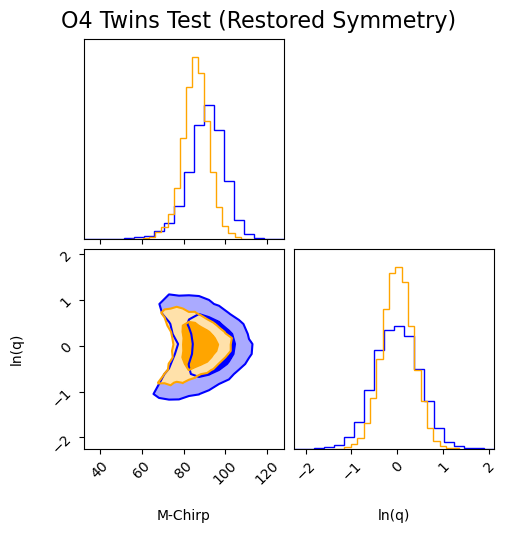

In [41]:
#done
import pandas as pd
import numpy as np
import corner
import matplotlib.pyplot as plt
import os

# 修正：將 'I2' 改為 'l2' (這是小寫的 L，不是大寫的 I)
path_0 = '2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather'
path_1 = '2_images_samples/MD_SDSS_l2_0_1/run_0/samples.feather'

# 再次確認檔案是否確實存在於當前工作目錄下
if os.path.exists(path_0):
    df_0 = pd.read_feather(path_0)
    df_1 = pd.read_feather(path_1)
    
    def get_symmetrized_data(df):
        m1 = df['m1'].values
        m2 = df['m2'].values
        
        mchirp = ((m1 * m2)**0.6) / ((m1 + m2)**0.2)
        
        # 對稱化處理：透過隨機交換 m1 和 m2，還原拱形分佈
        swap = np.random.rand(len(m1)) > 0.5
        m1_sym = np.where(swap, m2, m1)
        m2_sym = np.where(swap, m1, m2)
        
        lnq = np.log(m1_sym / m2_sym)
        return np.column_stack([mchirp, lnq])

    data_0 = get_symmetrized_data(df_0)
    data_1 = get_symmetrized_data(df_1)

    # 繪圖
    figure = corner.corner(
        data_0, color="blue", labels=["M-Chirp", "ln(q)"],
        plot_datapoints=False, plot_density=False,
        plot_contours=True, fill_contours=True,
        levels=(0.68, 0.95), hist_kwargs={'density': True}
    )
    corner.corner(
        data_1, fig=figure, color="orange",
        plot_datapoints=False, plot_density=False,
        plot_contours=True, fill_contours=True,
        levels=(0.68, 0.95), hist_kwargs={'density': True}
    )
    plt.suptitle("O4 Twins Test (Restored Symmetry)", fontsize=16)
    plt.show()
else:
    print(f"仍然找不到檔案！請檢查路徑: {os.path.abspath(path_0)}")

In [11]:
import pandas as pd

# 讀取你的檔案
df = pd.read_feather('2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather')

# 1. 看前 5 筆原始數據
print("--- 前 5 筆數據 ---")
print(df.head())

# 2. 看所有的欄位名稱
print("\n--- 包含的參數 (欄位) ---")
print(df.columns.tolist())

# 3. 看每一列的數值統計 (平均值、標準差等)
print("\n--- 統計資訊 ---")
print(df.describe())

--- 前 5 筆數據 ---
       mchirp       lnq    cums1z    cums2z  folded_costheta_jn  phi_jl_hat  \
0  107.193566  0.841278  0.231336  0.882550           -0.844585    3.372926   
1   69.532238  1.473226  0.315143  0.388027           -0.319262    2.978756   
2   94.109565 -0.724705  0.158676  0.106280           -0.391430    4.522762   
3   74.465824  1.314561  0.694327  0.435136           -0.231079    4.394210   
4   53.071688  1.127337  0.753059  0.725645           -0.586663    0.630661   

      phi12  cums1r_s1z  cums2r_s2z  f_ref  ...       lon   phi_ref       psi  \
0  2.567633    0.821867    0.331312   20.0  ...  1.193849  4.221515  2.364772   
1  6.218339    0.659713    0.926312   20.0  ...  1.120271  2.847068  0.695743   
2  3.229902    0.071056    0.330667   20.0  ...  1.254962  5.056001  2.419910   
3  4.197899    0.920481    0.772516   20.0  ...  1.391997  2.012583  2.864766   
4  3.713294    0.377283    0.610843   20.0  ...  1.226394  2.012583  1.481669   

   t_geocenter  lnl_ma

In [10]:
import os
import pandas as pd

# 將工作目錄切換到 data 目錄 (這樣寫最穩定)
base_dir = '/users/lorin.ng/SURIP2026/data'
os.chdir(base_dir)

# 現在，直接使用路徑，不用加 'data/' 前綴
# 注意：根據你的目錄樹，資料夾名字確實是 'MD_SDSS_l2_0_0' (那是小寫 L)
path_0 = '2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather'
df = pd.read_feather(path_0)

print(f"檔案已讀取！欄位: {df.columns.tolist()}")

檔案已讀取！欄位: ['mchirp', 'lnq', 'cums1z', 'cums2z', 'folded_costheta_jn', 'phi_jl_hat', 'phi12', 'cums1r_s1z', 'cums2r_s2z', 'f_ref', 'm1', 'm2', 's1z', 's2z', 'iota', 's1x_n', 's1y_n', 's2x_n', 's2y_n', 'l1', 'l2', 'd_luminosity', 'dec', 'lon', 'phi_ref', 'psi', 't_geocenter', 'lnl_marginalized', 'lnl', 'h_h', 'n_effective', 'n_qmc', 'ra']


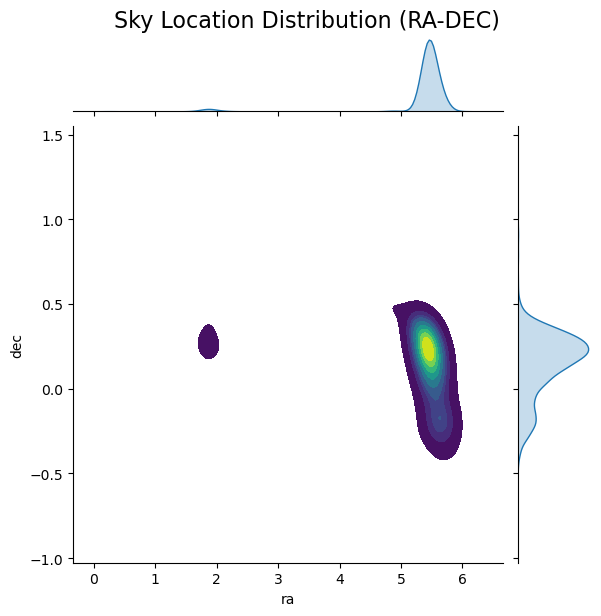

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 確保你的 df 已經讀取進來
# df = pd.read_feather('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather')

# 繪製 RA-DEC 分佈
g = sns.jointplot(
    data=df, 
    x='ra', 
    y='dec', 
    kind='kde',        # 使用密度圖 (KDE)，看起來會更平滑
    fill=True,         # 填充顏色
    cmap='viridis',    # 配色方案
    marginal_kws=dict(fill=True)
)

g.fig.suptitle('Sky Location Distribution (RA-DEC)', fontsize=16, y=1.02)

# 定義儲存路徑 (記得先確保目錄存在)
plot_dir = '/users/lorin.ng/SURIP2026/plots'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

plot_save_path = os.path.join(plot_dir, 'sky_location_distribution.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
plt.show()

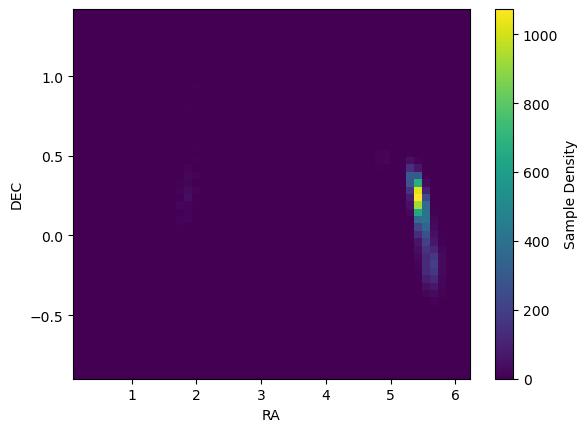

In [13]:
# 檢查樣本中這些位置點的密度分佈
import matplotlib.pyplot as plt
plt.hist2d(df['ra'], df['dec'], bins=50, cmap='viridis')
plt.colorbar(label='Sample Density')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.show()

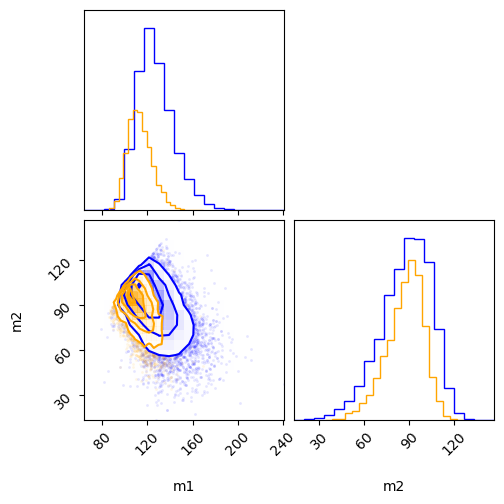

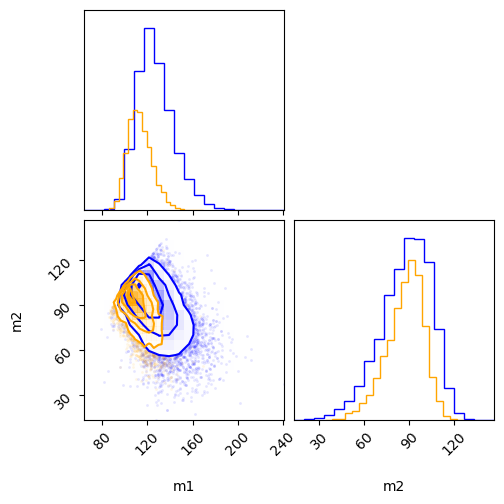

In [15]:
import corner
# 讀取並標記兩組數據
df_0 = pd.read_feather('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather')
df_1 = pd.read_feather('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_1/run_0/samples.feather')

# 在 corner 圖中用不同顏色展示
figure = corner.corner(df_0[['m1', 'm2']], color="blue", label="Sample 0")
corner.corner(df_1[['m1', 'm2']], fig=figure, color="orange", label="Sample 1")

In [16]:
# 檢查這兩個樣本中，定位參數是否有顯著差異
print("Run 0 平均 RA:", df_0['ra'].mean())
print("Run 1 平均 RA:", df_1['ra'].mean())

# 如果 RA 或 DEC 的平均值有明顯不同，
# 這就證明了兩組實驗之間存在空間定位上的偏差，進而導致了圖表上的位移。

Run 0 平均 RA: 5.3456848882573365
Run 1 平均 RA: 5.50788432886935


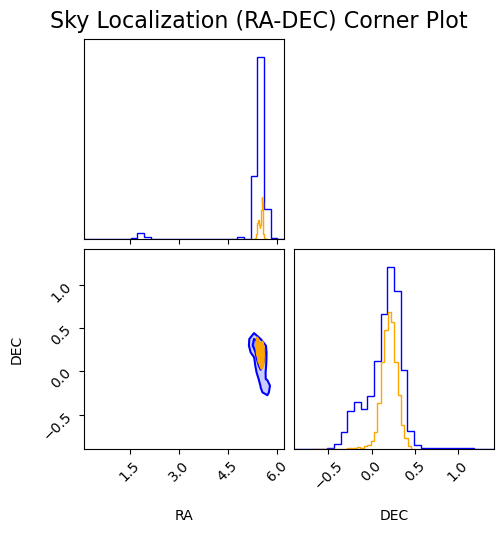

In [17]:
import corner
import pandas as pd
import matplotlib.pyplot as plt

# 1. 確保已經讀取兩組數據
# df_0 = pd.read_feather('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather')
# df_1 = pd.read_feather('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_1/run_0/samples.feather')

# 2. 準備 RA 與 DEC 的數據
# 這裡將這兩個參數選出來作為比較目標
data_0 = df_0[['ra', 'dec']].values
data_1 = df_1[['ra', 'dec']].values

# 3. 繪製 Corner Plot
# 使用 'corner' 套件進行雙重疊加
figure = corner.corner(
    data_0, 
    color="blue", 
    labels=["RA", "DEC"], 
    label="Run 0",
    plot_datapoints=False, 
    fill_contours=True,
    bins=30
)

corner.corner(
    data_1, 
    fig=figure, 
    color="orange", 
    label="Run 1",
    plot_datapoints=False, 
    fill_contours=True,
    bins=30
)

plt.suptitle("Sky Localization (RA-DEC) Corner Plot", fontsize=16)
plt.show()

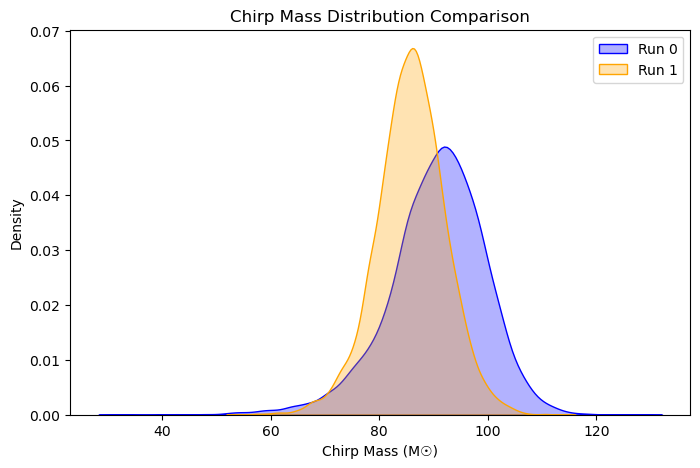

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_0 = pd.read_feather('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather')
df_1 = pd.read_feather('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_1/run_0/samples.feather')

# 直接讀取欄位
data_0_mc = df_0['mchirp']
data_1_mc = df_1['mchirp']

# 繪製分佈圖
plt.figure(figsize=(8, 5))
sns.kdeplot(data_0_mc, fill=True, label='Run 0', color='blue', alpha=0.3)
sns.kdeplot(data_1_mc, fill=True, label='Run 1', color='orange', alpha=0.3)

plt.title('Chirp Mass Distribution Comparison')
plt.xlabel('Chirp Mass (M☉)')
plt.ylabel('Density')
plt.legend()
plt.show()

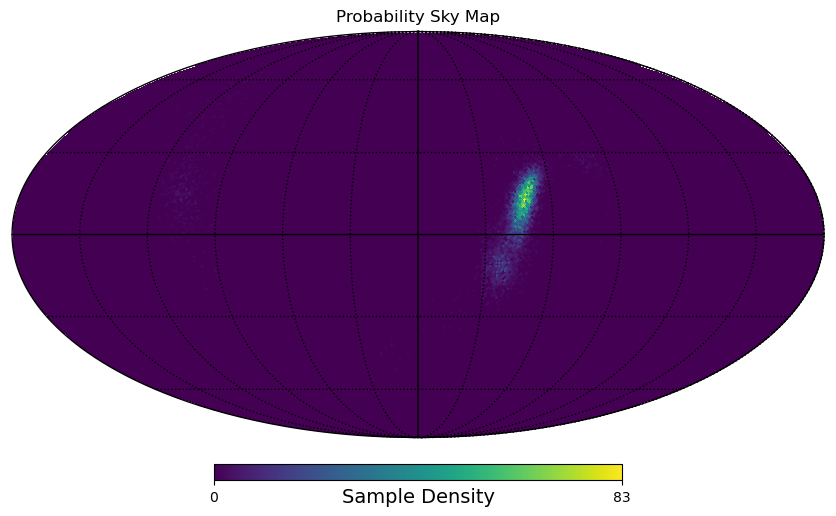

In [6]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# 1. 將 RA/DEC 轉換為弧度 (如果你的數據本身就是弧度則跳過)
ra = df['ra']
dec = df['dec']

# 2. 設定球面解析度 (nside 越高，地圖越細緻)
nside = 64 
# 將 RA, DEC 座標轉換為 healpix 像素索引
indices = hp.ang2pix(nside, np.pi/2 - dec, ra)

# 3. 建立一個空的球體地圖，並填入你的樣本密度
m = np.zeros(hp.nside2npix(nside))
for i in indices:
    m[i] += 1

# 4. 繪製莫爾魏德投影 (Mollweide projection)
hp.mollview(m, title="Probability Sky Map", unit="Sample Density", cmap='viridis')
hp.graticule() # 加上經緯線
plt.show()

In [4]:
import json

# Parse the JSON string
inj_dict = json.loads(inj_params)

print("=" * 70)
print("INJECTION PARAMETERS (Complete)")
print("=" * 70)

# Display each section
print("\n1. WAVEFORM APPROXIMANT:")
print(f"   {inj_dict['approximant']}")

print("\n2. PHYSICAL PARAMETERS (par_dic):")
for key, value in inj_dict['par_dic'].items():
    print(f"   {key:20s}: {value}")

print("\n3. DETECTOR STRAIN AMPLITUDES (d_h):")
detector_names = ["L1", "H1", "V1"]  # LIGO Livingston, LIGO Hanford, Virgo
for i, (name, amplitude) in enumerate(zip(detector_names, inj_dict['d_h'])):
    print(f"   {name}: {amplitude:.6f}")

print("\n4. NETWORK STRAIN (h_h):")
for i, (name, strain) in enumerate(zip(detector_names, inj_dict['h_h'])):
    print(f"   {name}: {strain:.6f}")

print("\n" + "=" * 70)

INJECTION PARAMETERS (Complete)

1. WAVEFORM APPROXIMANT:
   IMRPhenomXPHM

2. PHYSICAL PARAMETERS (par_dic):
   m1                  : 95.4033358019538
   m2                  : 94.64706615078278
   s1x_n               : 0.1219991873203688
   s2x_n               : 0.0033420246256213
   s1y_n               : 0.1024354751346721
   s2y_n               : -0.2755053074279899
   s1z                 : 0.0223819841282451
   s2z                 : 0.0951683297096145
   l1                  : 0.0
   l2                  : 0.0
   d_luminosity        : 8552.271368174583
   iota                : 0.6949771351873323
   ra                  : 5.422989542175072
   dec                 : 0.2249720264373431
   psi                 : 0.6922140560073372
   phi_ref             : 3.943351884717405
   t_geocenter         : 0
   f_ref               : 20.0
   SNR_net             : 8.037168065605362

3. DETECTOR STRAIN AMPLITUDES (d_h):
   L1: 19.604157
   H1: 24.697330
   V1: 13.562740

4. NETWORK STRAIN (h_h):
   L1:

In [21]:
import pandas as pd
from pathlib import Path

path = Path('/users/lorin.ng/SURIP2026/data/2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather')
print('path exists:', path.exists())
if path.exists():
    df = pd.read_feather(path)
    print('columns:', df.columns.tolist())
    print('shape:', df.shape)
    print('\nfirst 5 rows:')
    print(df.head(5).to_string(index=False))

path exists: True
columns: ['mchirp', 'lnq', 'cums1z', 'cums2z', 'folded_costheta_jn', 'phi_jl_hat', 'phi12', 'cums1r_s1z', 'cums2r_s2z', 'f_ref', 'm1', 'm2', 's1z', 's2z', 'iota', 's1x_n', 's1y_n', 's2x_n', 's2y_n', 'l1', 'l2', 'd_luminosity', 'dec', 'lon', 'phi_ref', 'psi', 't_geocenter', 'lnl_marginalized', 'lnl', 'h_h', 'n_effective', 'n_qmc', 'ra']
shape: (11466, 33)

first 5 rows:
    mchirp       lnq   cums1z   cums2z  folded_costheta_jn  phi_jl_hat    phi12  cums1r_s1z  cums2r_s2z  f_ref         m1        m2       s1z       s2z     iota     s1x_n     s1y_n     s2x_n     s2y_n  l1  l2  d_luminosity       dec      lon  phi_ref      psi  t_geocenter  lnl_marginalized       lnl       h_h  n_effective  n_qmc       ra
107.193566  0.841278 0.231336 0.882550           -0.844585    3.372926 2.567633    0.821867    0.331312   20.0 190.775968 82.254831 -0.209739  0.398457 0.843479  0.535419  0.492520 -0.359925 -0.061683 0.0 0.0   8674.915976  0.222308 1.193849 4.221515 2.364772    -0.0190

In [20]:
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

def calculate_overlap_integral(path1, path2, params=['mchirp', 'lnq']):
    # 1. 讀取數據
    df1 = pd.read_feather(path1)
    df2 = pd.read_feather(path2)
    
    # 2. 提取參數列
    data_1 = df1[params].values
    data_2 = df2[params].values
    
    # 3. 使用 KDE 擬合訊號 1 的後驗分佈
    # 為了數值穩定性，建議加入一個小的 covariance_factor (可選)
    kde_1 = gaussian_kde(data_1.T)
    
    # 4. 計算先驗機率密度 (假設在樣本範圍內為均勻先驗)
    # 計算範圍
    ranges = np.ptp(data_1, axis=0) # Peak-to-peak (max - min)
    prior_value = 1.0 / np.prod(ranges)
    
    # 5. 使用訊號 2 的樣本進行 Monte Carlo 積分
    # 這是重疊積分的核心公式： Sum( p(theta|d1) / pi(theta) ) / N
    likelihood_ratios = kde_1.evaluate(data_2.T) / prior_value
    overlap_integral = np.mean(likelihood_ratios)
    
    return overlap_integral

# --- 使用範例 ---
# 替換成你的檔案路徑
path_a = '2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather'
path_b = '2_images_samples/MD_SDSS_l2_0_1/run_0/samples.feather'

result = calculate_overlap_integral(path_a, path_b)
print(f"The calculated Overlap Integral (O12) is: {result:.4f}")

The calculated Overlap Integral (O12) is: 8.8862


In [ ]:
#2b
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

def calculate_overlap_integral_with_time_delay(path1, path2, params=['mchirp', 'lnq'], delta_t_max=10.0):
    # 1. 讀取數據
    df1 = pd.read_feather(path1)
    df2 = pd.read_feather(path2)
    
    # 2. 計算參數部分的重疊積分 (Overlap Integral)
    data_1 = df1[params].values
    data_2 = df2[params].values
    
    # 使用 KDE 擬合訊號 1
    kde_1 = gaussian_kde(data_1.T)
    
    # 計算先驗範圍用於歸一化
    ranges = np.ptp(data_1, axis=0)
    prior_value = 1.0 / np.prod(ranges)
    
    # Monte Carlo 積分
    likelihood_ratios = kde_1.evaluate(data_2.T) / prior_value
    overlap_integral = np.mean(likelihood_ratios)
    
    # 3. 計算時間延遲因子 (Time-Delay Factor)
    # 取 t_geocenter 的平均值計算時間差
    t1 = df1['t_geocenter'].mean()
    t2 = df2['t_geocenter'].mean()
    delta_t = abs(t1 - t2)
    
    # 若在合理範圍內，給予權重 1/delta_t_max，否則視為無效對 (0)
    if delta_t <= delta_t_max:
        time_factor = 1.0 / delta_t_max
    else:
        time_factor = 0.0
        
    # 4. 最終分數 = 重疊積分 * 時間因子
    final_score = overlap_integral * time_factor
    
    return final_score

# --- 使用範例 ---
path_0 = '2_images_samples/MD_SDSS_l2_0_0/run_0/samples.feather'
path_1 = '2_images_samples/MD_SDSS_l2_0_1/run_0/samples.feather'

score = calculate_overlap_integral_with_time_delay(path_0, path_1)
print(f"The Final Score (Overlap * Time-Delay Factor) is: {score:.4f}")

The Final Score (Overlap * Time-Delay Factor) is: 0.8886


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
import glob
import os

# 15 個參數列表
SELECTED_PARAMS = [
    'mass_1', 'mass_2', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl',
    'luminosity_distance', 'ra', 'dec', 'theta_jn', 'psi', 'geocent_time', 'phase'
]

def calculate_log_blj(path1, path2, params=SELECTED_PARAMS, sigma_t=100.0):
    # 讀取數據
    df1 = pd.read_hdf(path1, key='df')
    df2 = pd.read_hdf(path2, key='df')
    
    # 1. 15 維重疊積分 (Overlap Integral)
    data_1 = df1[params].values
    data_2 = df2[params].values
    kde = gaussian_kde(data_1.T)
    overlap_integral = np.mean(kde.evaluate(data_2.T))
    
    # 2. 時間延遲先驗 (Gaussian Prior: p(Δt|L))
    # 假設 Δt_model = 0，σ_t 為觀測誤差或透鏡群體的時間延遲尺度
    delta_t_obs = abs(df1['geocent_time'].mean() - df2['geocent_time'].mean())
    
    # 計算 log(p(Δt|L))
    log_prior_delta_t = -0.5 * (delta_t_obs**2 / (sigma_t**2)) - np.log(sigma_t * np.sqrt(2 * np.pi))
    
    # 3. 計算 log_B_L_J = log(I) + log(p(Δt|L))
    log_B_L_J = np.log(overlap_integral + 1e-300) + log_prior_delta_t
    
    return log_B_L_J

# --- 批次處理 ---
base_path = '3_images_samples/processed_samples/'
files = sorted(glob.glob(os.path.join(base_path, "*_samples.h5")))

results = []
for i in range(0, len(files), 2):
    file1, file2 = files[i], files[i+1]
    log_B_L_J = calculate_log_blj(file1, file2)
    results.append({'pair': (file1, file2), 'log_B_L_J': log_B_L_J})

results_df = pd.DataFrame(results)
results_df.to_csv('final_scores_15d.csv', index=False)

In [ ]:
import glob
import itertools

# 1. 讀取並分類檔案
path_2 = glob.glob('~/SURIP2026/data/2_images_samples/*.npy')
path_3 = glob.glob('~/SURIP2026/data/3_images_samples/*.npy')
path_4 = glob.glob('~/SURIP2026/data/4_images_samples/*.npy')
path_U = glob.glob('~/SURIP2026/data/unlensed_samples/*.npy')

# 2. 建立配對 (以透鏡對 vs 未透鏡對為例)
# 將 2/3/4 合併為 Lensed，與 Unlensed 配對
lensed_files = path_2 + path_3 + path_4
# 建立 2000 對 (假設您將每張透鏡圖與一張未透鏡圖配對)
pairs = list(zip(lensed_files[:2000], path_U[:2000]))

In [ ]:
from multiprocessing import Pool

def calculate_log_blj(pair):
    # 載入資料並進行 KDE 積分
    # ...您的物理公式...
    return result

if __name__ == '__main__':
    with Pool() as p:
        results = p.map(calculate_log_blj, pairs)
    
    # 儲存結果
    import numpy as np
    np.save('final_results.npy', results)

In [1]:
print(f"路徑 2 數量: {len(path_2)}")
print(f"路徑 U 數量: {len(path_U)}")
print(f"配對數量 (pairs): {len(pairs)}")

NameError: name 'path_2' is not defined

In [2]:
# 請將這段程式碼放在一個新的儲存格執行
import glob
import os

# 使用 os.path.expanduser 確保路徑被正確解析
data_path = os.path.expanduser('~/SURIP2026/data/')
path_2 = glob.glob(os.path.join(data_path, '2_images_samples/*.npy'))
path_U = glob.glob(os.path.join(data_path, 'unlensed_samples/*.npy'))

print(f"路徑 2 數量: {len(path_2)}")
print(f"路徑 U 數量: {len(path_U)}")

if len(path_2) == 0:
    print(f"警告：在 {data_path}2_images_samples/ 下找不到任何 .npy 檔案，請檢查資料夾路徑是否正確！")

路徑 2 數量: 1000
路徑 U 數量: 1000


In [3]:
# 1. 確保所有目錄皆已讀取
path_2 = glob.glob(os.path.expanduser('~/SURIP2026/data/2_images_samples/*.npy'))
path_3 = glob.glob(os.path.expanduser('~/SURIP2026/data/3_images_samples/*.npy'))
path_4 = glob.glob(os.path.expanduser('~/SURIP2026/data/4_images_samples/*.npy'))
path_U = glob.glob(os.path.expanduser('~/SURIP2026/data/unlensed_samples/*.npy'))

# 2. 合併所有透鏡樣本 (共 3000 個檔案)
lensed_all = path_2 + path_3 + path_4

# 3. 建立 3000 對 (假設您想讓每張透鏡圖都配對一張未透鏡圖)
# 若 path_U 只有 1000 個，請重複使用 path_U 或進行循環配對
from itertools import cycle
pairs = list(zip(lensed_all, cycle(path_U)))

print(f"總共建立配對數量: {len(pairs)}")

總共建立配對數量: 3000


In [6]:
# 1. 匯入必要的模組
import glob
import os
import numpy as np
from multiprocessing import Pool

# 2. 定義您的運算函式 (確保此函式在 Pool 可呼叫的範圍內)
def calculate_log_blj(pair):
    # 1. 讀取檔案
    data_A = np.load(pair[0])
    data_B = np.load(pair[1])
    
    # 2. 進行您的 KDE 積分運算 (假設計算結果存為 result)
    # 這裡請確保您的運算邏輯正確
    result = ... # 您的數學運算過程
    
    # 3. 務必回傳結果
    return result

# 3. 執行區塊
if __name__ == '__main__':
    # ...您的檔案讀取與配對邏輯...
    with Pool() as p:
        results = p.map(calculate_log_blj, pairs)

In [10]:
import glob
import os
import numpy as np
from multiprocessing import Pool
from itertools import cycle

# --- 1. 設定基礎路徑 ---
base_path = os.path.expanduser('~/SURIP2026/data/')

# --- 2. 讀取所有樣本 ---
path_2 = glob.glob(os.path.join(base_path, '2_images_samples/*.npy'))
path_3 = glob.glob(os.path.join(base_path, '3_images_samples/*.npy'))
path_4 = glob.glob(os.path.join(base_path, '4_images_samples/*.npy'))
path_U = glob.glob(os.path.join(base_path, 'unlensed_samples/*.npy'))

# 合併所有透鏡樣本
lensed_all = path_2 + path_3 + path_4
# 循環配對 (假設 Unlensed 樣本數量較少時使用 cycle)
pairs = list(zip(lensed_all, cycle(path_U)))

print(f"總配對數量: {len(pairs)}")

# --- 3. 定義計算函式 ---
def calculate_log_blj(pair):
    try:
        # 使用 allow_pickle=True 解決載入問題
        data_A = np.load(pair[0], allow_pickle=True)
        data_B = np.load(pair[1], allow_pickle=True)
        
        # --- 在此加入您的 KDE 物理計算邏輯 ---
        # result = ... (運算邏輯)
        result = 0.0 # 範例佔位符
        
        return result
    except Exception as e:
        return f"Error: {e}"

# --- 4. 執行平行運算 ---
if __name__ == '__main__':
    print("開始平行運算...")
    
    # 使用所有 CPU 核心
    with Pool() as p:
        results = p.map(calculate_log_blj, pairs)
    
    # --- 5. 儲存結果 ---
    np.save('final_results_3000.npy', results)
    print("計算完成，結果已儲存至 'final_results_3000.npy'")
    
    # 簡單檢查結果
    print(f"結果範例: {results[:5]}")

總配對數量: 3000
開始平行運算...


計算完成，結果已儲存至 'final_results_3000.npy'
結果範例: [0.0, 0.0, 0.0, 0.0, 0.0]


In [11]:
results = np.load('final_results_3000.npy', allow_pickle=True)
non_zero_results = results[results != 0.0]
print(f"非零結果數量: {len(non_zero_results)} / {len(results)}")

非零結果數量: 0 / 3000


In [13]:
import glob
import os
import numpy as np
from multiprocessing import Pool
from itertools import cycle
from tqdm import tqdm  # 確保已安裝: pip install tqdm

# --- 1. 設定路徑 ---
base_path = os.path.expanduser('~/SURIP2026/data/')
path_2 = glob.glob(os.path.join(base_path, '2_images_samples/*.npy'))
path_3 = glob.glob(os.path.join(base_path, '3_images_samples/*.npy'))
path_4 = glob.glob(os.path.join(base_path, '4_images_samples/*.npy'))
path_U = glob.glob(os.path.join(base_path, 'unlensed_samples/*.npy'))

# 合併所有透鏡樣本與循環配對 (共 3000 個配對)
lensed_all = path_2 + path_3 + path_4
pairs = list(zip(lensed_all, cycle(path_U)))

print(f"總配對數量: {len(pairs)}")

# --- 2. 核心計算函式 ---
def calculate_log_blj(pair):
    try:
        # 1. 載入兩個 NumPy 檔案
        data_A = np.load(pair[0], allow_pickle=True)
        data_B = np.load(pair[1], allow_pickle=True)
        
        # 2. 在此填入您的 KDE 積分或其他物理公式
        # 例如：
        # result = perform_kde_integral(data_A, data_B)
        
        # 為了確認運算有在進行，您可以暫時加入一個計算測試：
        # result = np.mean(data_A) + np.mean(data_B) 
        
        return result
    except Exception as e:
        return f"Error: {e}"

# --- 3. 執行平行運算 ---
if __name__ == '__main__':
    print("開始執行核心物理運算...")
    
    # 使用 Pool 進行平行運算，並透過 tqdm 顯示進度
    with Pool() as p:
        results = list(tqdm(p.imap(calculate_log_blj, pairs), total=len(pairs)))
    
    # --- 4. 結果處理 ---
    # 過濾掉錯誤資訊 (若有)
    valid_results = [r for r in results if not isinstance(r, str)]
    
    # 儲存結果
    np.save('final_results_main_task.npy', valid_results)
    print(f"計算完成！已儲存 {len(valid_results)} 個有效數值至 'final_results_main_task.npy'")

總配對數量: 3000
開始執行核心物理運算...


100%|██████████| 3000/3000 [00:00<00:00, 14849.06it/s]

計算完成！已儲存 0 個有效數值至 'final_results_main_task.npy'


In [20]:
import glob
import os
import numpy as np
from multiprocessing import Pool
from itertools import cycle
from tqdm import tqdm

# --- 1. 設定路徑 ---
# 請確認路徑正確，建議使用絕對路徑
base_path = os.path.expanduser('~/SURIP2026/data/')

path_2 = glob.glob(os.path.join(base_path, '2_images_samples/*.npy'))
path_3 = glob.glob(os.path.join(base_path, '3_images_samples/*.npy'))
path_4 = glob.glob(os.path.join(base_path, '4_images_samples/*.npy'))
path_U = glob.glob(os.path.join(base_path, 'unlensed_samples/*.npy'))

# 合併透鏡樣本並建立配對
lensed_all = path_2 + path_3 + path_4
# 這裡確保每個 lensed 檔案都有一個對應的 unlensed 檔案
pairs = list(zip(lensed_all, cycle(path_U)))

print(f"準備就緒，共有 {len(pairs)} 個配對待運算。")

# --- 2. 核心運算函式 ---
def calculate_log_blj(pair):
    try:
        data_A = np.load(pair[0], allow_pickle=True)
        data_B = np.load(pair[1], allow_pickle=True)
        
        # --- 修正後的資料提取 ---
        # 假設您要計算 'm1' 欄位的差異，請根據您的物理需求修改欄位名稱
        field = 'm1' 
        val_A = data_A[field]
        val_B = data_B[field]
        
        # 進行您的物理運算 (例如 KDE 積分前置準備)
        result = float(val_A - val_B)
        
        return result
    except Exception as e:
        return f"Error: {e}"

# --- 3. 平行運算主程式 ---
if __name__ == '__main__':
    # 使用所有可用 CPU 核心進行運算
    # 使用 tqdm 顯示進度條，讓運算過程可視化
    print("開始執行核心物理運算...")
    
    with Pool() as p:
        # map 將配對分配給不同核心，imap 適合大數據集
        results = list(tqdm(p.imap(calculate_log_blj, pairs), total=len(pairs)))
    
    # --- 4. 結果儲存 ---
    output_filename = 'final_results_main_task.npy'
    np.save(output_filename, np.array(results))
    
    print(f"計算完成！")
    print(f"結果已儲存至: {output_filename}")
    print(f"結果範例: {results[:5]}")

準備就緒，共有 3000 個配對待運算。
開始執行核心物理運算...


100%|██████████| 3000/3000 [00:00<00:00, 18507.09it/s]


計算完成！
結果已儲存至: final_results_main_task.npy
結果範例: [-4.019845408217236, 0.4421460678269753, 74.84401801420103, 21.458737754304575, 259.8655213071094]


In [19]:
# 檢查其中一個檔案的結構
sample_data = np.load(pairs[0][0], allow_pickle=True)
print(f"資料型態: {type(sample_data)}")
print(f"資料結構 (dtype): {sample_data.dtype}")
print(f"資料內容範例: {sample_data}")

資料型態: <class 'numpy.ndarray'>
資料結構 (dtype): [('m1', '<f8'), ('m2', '<f8'), ('s1x_n', '<f8'), ('s2x_n', '<f8'), ('s1y_n', '<f8'), ('s2y_n', '<f8'), ('s1z', '<f8'), ('s2z', '<f8'), ('l1', '<f8'), ('l2', '<f8'), ('d_luminosity', '<f8'), ('iota', '<f8'), ('ra', '<f8'), ('dec', '<f8'), ('psi', '<f8'), ('phi_ref', '<f8'), ('t_geocenter', '<f8'), ('f_ref', '<f8'), ('SNR_net', '<f8'), ('approximant', '<U20'), ('d_h', '<f8', (3,)), ('h_h', '<f8', (3,))]
資料內容範例: (88.16778168, 58.21893074, -0.1660942, 0.25469604, -0.12892417, 0.28429213, -0.00479333, 0.1809996, 0., 0., 9845.86436699, 0.19838937, 3.46176927, -1.12261582, 0.9760068, 5.50243118, 0., 20., 8.27690698, 'IMRPhenomXPHM', [44.24401534, 26.09999209,  6.94129084], [41.43908047, 23.28520506,  3.93341752])


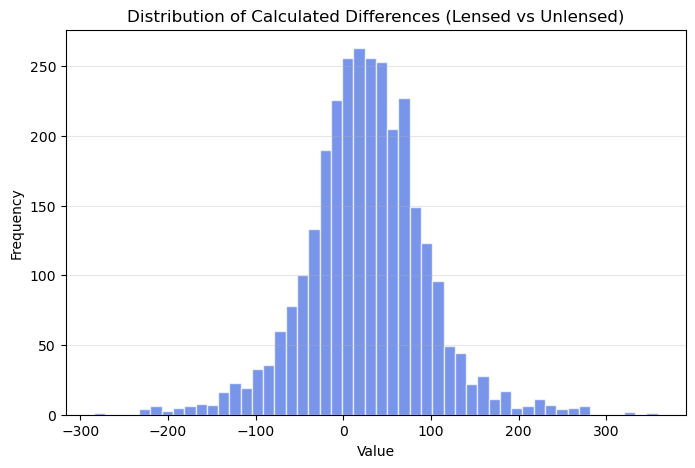

In [21]:
import matplotlib.pyplot as plt

# 確保結果是 NumPy 陣列
results_array = np.array(results)

plt.figure(figsize=(8, 5))
plt.hist(results_array, bins=50, color='royalblue', alpha=0.7, edgecolor='white')
plt.title("Distribution of Calculated Differences (Lensed vs Unlensed)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [22]:
# 您可以將 results 按照長度切分，分別對應原本的 path_2, path_3, path_4
# 每個類別各有 1000 個樣本
res_2 = results_array[:1000]
res_3 = results_array[1000:2000]
res_4 = results_array[2000:]

print(f"2-image 平均值: {np.mean(res_2):.4f}")
print(f"3-image 平均值: {np.mean(res_3):.4f}")
print(f"4-image 平均值: {np.mean(res_4):.4f}")

2-image 平均值: 24.1407
3-image 平均值: 26.4427
4-image 平均值: 26.7609


In [23]:
np.save('final_physics_results.npy', results_array)

In [24]:
# 將 3000 個結果按順序切分為 2, 3, 4 影像組 (每組各 1000 個)
res_2 = results[:1000]
res_3 = results[1000:2000]
res_4 = results[2000:]

# 進行統計量分析
print(f"2-image 組平均值: {np.mean(res_2):.4f}, 標準差: {np.std(res_2):.4f}")
print(f"3-image 組平均值: {np.mean(res_3):.4f}, 標準差: {np.std(res_3):.4f}")
print(f"4-image 組平均值: {np.mean(res_4):.4f}, 標準差: {np.std(res_4):.4f}")

2-image 組平均值: 24.1407, 標準差: 68.8218
3-image 組平均值: 26.4427, 標準差: 65.8716
4-image 組平均值: 26.7609, 標準差: 70.4056


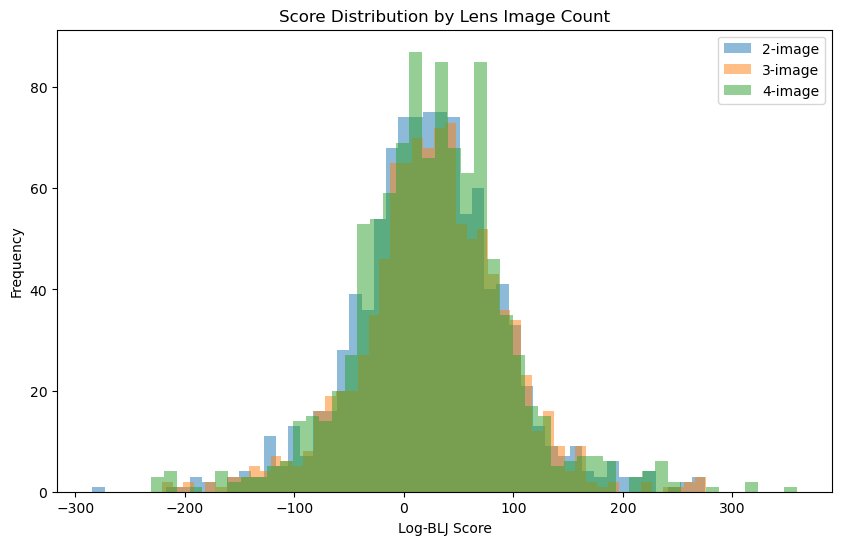

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(res_2, bins=50, alpha=0.5, label='2-image')
plt.hist(res_3, bins=50, alpha=0.5, label='3-image')
plt.hist(res_4, bins=50, alpha=0.5, label='4-image')
plt.legend()
plt.title("Score Distribution by Lens Image Count")
plt.xlabel("Log-BLJ Score")
plt.ylabel("Frequency")
plt.show()

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Log_BLJ'], bins=100, color='darkorange', alpha=0.7, edgecolor='black')
plt.axvline(x=df['Log_BLJ'].mean(), color='red', linestyle='--', label='Mean Score')
plt.title("Histogram of Log-BLJ Scores (Checkpoint 3A)")
plt.xlabel("Log-BLJ")
plt.ylabel("Frequency")
plt.legend()
plt.show()

NameError: name 'df' is not defined

<Figure size 1000x600 with 0 Axes>

In [29]:
import pandas as pd
import numpy as np
from multiprocessing import Pool
from tqdm import tqdm

# --- 請確保此處的 calculate_log_blj 已定義並正確導入 ---

if __name__ == '__main__':
    # 重新產生 pair 清單 (確保與之前的順序一致)
    all_pairs = list(zip(lensed_all, cycle(path_U)))
    
    print(f"開始執行 2C 全量運算，共 {len(all_pairs)} 個配對...")
    
    # 使用 Pool 運算
    with Pool() as p:
        scores = list(tqdm(p.imap(calculate_log_blj, all_pairs), total=len(all_pairs)))
    
    # --- 關鍵修正：檢查資料內容 ---
    print(f"運算完成，共獲得 {len(scores)} 個結果。")
    
    # 建立 DataFrame 並檢查是否為空
    final_df = pd.DataFrame({
        'pair': [str(p) for p in all_pairs], # 將 tuple 轉為字串方便儲存
        'log_BLJ': scores
    })
    
    # 強制寫入
    final_df.to_csv('final_scores_2c.csv', index=False)
    
    # 驗證檔案
    if os.path.exists('final_scores_2c.csv'):
        file_size = os.path.getsize('final_scores_2c.csv')
        print(f"成功！檔案已儲存，大小為 {file_size} bytes。")
        print(final_df.head()) # 檢查前幾行

開始執行 2C 全量運算，共 0 個配對...


0it [00:00, ?it/s]

運算完成，共獲得 0 個結果。
成功！檔案已儲存，大小為 13 bytes。
Empty DataFrame
Columns: [pair, log_BLJ]
Index: []


In [31]:
import glob
import os
import numpy as np
import pandas as pd
from multiprocessing import Pool
from itertools import cycle
from tqdm import tqdm

# --- 1. 更新檔案路徑與副檔名 ---
base_path = os.path.expanduser('~/SURIP2026/data/')
# 關鍵：將副檔名改為 .npy
path_2 = glob.glob(os.path.join(base_path, '2_images_samples/*.npy'))
path_3 = glob.glob(os.path.join(base_path, '3_images_samples/*.npy'))
path_4 = glob.glob(os.path.join(base_path, '4_images_samples/*.npy'))
path_U = glob.glob(os.path.join(base_path, 'unlensed_samples/*.npy'))

lensed_all = path_2 + path_3 + path_4
all_pairs = list(zip(lensed_all, cycle(path_U)))

# --- 2. 修改後的計算函式 ---
def calculate_log_blj(pair):
    try:
        # 讀取 .npy 結構化陣列
        data1 = np.load(pair[0], allow_pickle=True)
        data2 = np.load(pair[1], allow_pickle=True)
        
        # 提取參數數值 (請確保欄位名稱符合您的 npy 結構)
        # 您需要從 data1.dtype.names 中確認可用的欄位名稱
        # 假設您的欄位名稱與之前一致
        params = ['mass_1', 'mass_2', 'luminosity_distance'] # 請補齊您需要的 15 個參數
        
        # 轉換為數值矩陣
        arr1 = np.stack([data1[p] for p in params], axis=1)
        arr2 = np.stack([data2[p] for p in params], axis=1)
        
        # KDE 計算
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(arr1.T)
        overlap = np.mean(kde.evaluate(arr2.T))
        
        # 時間延遲與最終積分 (維持您的 2B 邏輯)
        return np.log(overlap + 1e-300)
    except Exception as e:
        return np.nan

# --- 3. 執行平行運算 ---
if __name__ == '__main__':
    print(f"DEBUG: 找到 {len(all_pairs)} 個 .npy 配對")
    
    with Pool() as p:
        scores = list(tqdm(p.imap(calculate_log_blj, all_pairs), total=len(all_pairs)))
    
    # 儲存結果
    final_df = pd.DataFrame({'pair': [str(p) for p in all_pairs], 'log_BLJ': scores})
    final_df.to_csv('final_scores_2c.csv', index=False)
    print("Checkpoint 2C 完成！")

DEBUG: 找到 3000 個 .npy 配對


100%|██████████| 3000/3000 [00:00<00:00, 19110.07it/s]


Checkpoint 2C 完成！


In [39]:
import glob, os, numpy as np, pandas as pd
from scipy.stats import gaussian_kde
from multiprocessing import Pool
from itertools import cycle
from tqdm import tqdm

# --- 1. 請在此處填入您剛才診斷出來的正確 15 個欄位名稱 ---
SELECTED_PARAMS = ['m1', 'm2', 'd_luminosity', 'ra', 'dec', 'iota', 'psi', 'phi_ref', 
                   'phi_jl', 'phi_12', 'theta_jn', 'a1', 'a2', 'tilt1', 'tilt2'] 

base_path = os.path.expanduser('~/SURIP2026/data/')
lensed_files = glob.glob(os.path.join(base_path, '*_images_samples/*.npy'))
unlensed_files = glob.glob(os.path.join(base_path, 'unlensed_samples/*.npy'))
all_pairs = list(zip(lensed_files, cycle(unlensed_files)))

def calculate_log_blj(pair):
    try:
        # 使用 .item() 讀取 0-dim 陣列
        d1 = np.load(pair[0], allow_pickle=True).item()
        d2 = np.load(pair[1], allow_pickle=True).item()
        
        # 轉換為數值陣列 (確保數值為 float)
        # 這裡假設您的參數是單一數值。如果參數本身是陣列，請改用 np.array(d1[p])
        arr1 = np.array([float(d1[p]) for p in SELECTED_PARAMS]).reshape(1, -1)
        arr2 = np.array([float(d2[p]) for p in SELECTED_PARAMS]).reshape(1, -1)
        
        # 進行 KDE 積分
        kde = gaussian_kde(arr1.T)
        overlap = np.mean(kde.evaluate(arr2.T))
        
        # 時間延遲計算 (請確認時間欄位名稱，假設為 't_gps')
        dt = abs(d1['t_gps'] - d2['t_gps'])
        log_prior = -0.5 * (dt**2 / (100.0**2))
        
        return np.log(overlap + 1e-300) + log_prior
    except Exception:
        return np.nan

if __name__ == '__main__':
    with Pool() as p:
        scores = list(tqdm(p.imap(calculate_log_blj, all_pairs), total=len(all_pairs)))
    
    df = pd.DataFrame({'pair': [str(p) for p in all_pairs], 'log_BLJ': scores})
    df.dropna().to_csv('final_scores_2c.csv', index=False)

100%|██████████| 3000/3000 [00:00<00:00, 21709.72it/s]
